## Step 1: Business Understanding


#### 1.1 Business Background

Vendor performance directly impacts procurement costs, profitability, inventory efficiency, and supply chain risk.

This project analyzes procurement, sales, inventory, pricing, and vendor data to identify performance gaps and opportunities for procurement optimization.

#### 1.2 Business Problem

The business needs to identify which vendors create the most value, where procurement costs can be optimized, and whether inventory or supplier concentration creates financial and operational risks.

#### 1.3 Business Objectives

- Evaluate vendor profitability and procurement efficiency.
- Identify cost and inventory optimization opportunities.
- Assess supplier concentration and dependency risk.
- Segment vendors to support strategic procurement decisions.
- Translate analytical findings into actionable business recommendations.

#### 1.4 Key Business Questions

1. Which vendors generate the highest financial value?
2. Which vendors or products show potential cost or inventory inefficiencies?
3. How concentrated is procurement spending across suppliers?
4. Which vendors should be prioritized, renegotiated, or reviewed?

#### 1.5 Key Performance Indicators (KPIs)

| KPI | Business Purpose |
|---|---|
| Purchase Spend | Measure procurement investment |
| Sales Revenue | Measure vendor contribution |
| Gross Profit | Measure financial value |
| Profit Margin | Measure profitability efficiency |
| Sales-to-Purchase Ratio | Measure procurement efficiency |
| Inventory Turnover | Measure inventory efficiency |
| Vendor Spend Contribution | Measure supplier dependency |

#### 1.6 Success Criteria

The analysis should identify key vendor performance drivers, quantify procurement and inventory risks, and provide actionable recommendations to improve sourcing efficiency and supplier management.

#### 1.7 Project Workflow

**Data Preparation → Data Understanding → Data Cleaning → Data Integration → Feature Engineering → Business Analysis → Vendor Segmentation → Insights & Recommendations**

## Step 2: Data Preparation

This step prepares the seven datasets for analysis by setting up the analytical environment, loading the data, and establishing the relationship between procurement, sales, inventory, pricing, and vendor information.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


#### 2.2 Mount Google Drive

Connect Google Colab to Google Drive to access the project datasets stored externally.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### 2.3 Define Data Path

Define the directory containing the seven CSV files to ensure consistent and efficient data access throughout the analysis.

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Data Analyst Projects/Vendor Performance Analytics/"

In [ ]:
import os

print(os.listdir(DATA_PATH))

['end_inventory.csv', 'begin_inventory.csv', 'purchases.csv', 'purchase_prices.csv', 'sales.csv', 'vendor_invoice.csv', 'vendor_sales_summary.csv']


#### 2.4 Load Datasets

Load the seven datasets into pandas DataFrames and review their dimensions to understand the scale of the data.

In [ ]:
file_names = {
    "purchases": "purchases.csv",
    "sales": "sales.csv",
    "begin_inventory": "begin_inventory.csv",
    "end_inventory": "end_inventory.csv",
    "purchase_prices": "purchase_prices.csv",
    "vendor_invoice": "vendor_invoice.csv",
    "vendor_sales_summary": "vendor_sales_summary.csv"
}

data = {}

for name, file in file_names.items():
    data[name] = pd.read_csv(DATA_PATH + file)
    print(f"{name}: {data[name].shape}")

purchases: (2372474, 16)
sales: (12825363, 14)
begin_inventory: (206529, 9)
end_inventory: (224489, 9)
purchase_prices: (12261, 9)
vendor_invoice: (5543, 10)
vendor_sales_summary: (10692, 18)


## Step 3: Data Understanding

This step examines the structure, quality, and key characteristics of the seven datasets before data cleaning and analysis.

#### 3.1 Dataset Overview

Review the available datasets and their business purpose to establish a clear understanding of the data sources used in the analysis.

In [ ]:
dataset_overview = pd.DataFrame({
    "Dataset": [
        "Purchases",
        "Sales",
        "Begin Inventory",
        "End Inventory",
        "Purchase Prices",
        "Vendor Invoice",
        "Vendor Sales Summary"
    ],
    "Business Purpose": [
        "Procurement transactions",
        "Sales transactions",
        "Opening inventory",
        "Closing inventory",
        "Purchase pricing",
        "Vendor invoice information",
        "Vendor-level performance"
    ]
})

dataset_overview

,Dataset,Business Purpose
0,Purchases,Procurement transactions
1,Sales,Sales transactions
2,Begin Inventory,Opening inventory
3,End Inventory,Closing inventory
4,Purchase Prices,Purchase pricing
5,Vendor Invoice,Vendor invoice information
6,Vendor Sales Summary,Vendor-level performance


#### 3.2 Dataset Dimensions

Examine the number of records and variables in each dataset to understand the scale of the available data.

In [ ]:
dataset_dimensions = pd.DataFrame({
    "Dataset": data.keys(),
    "Rows": [df.shape[0] for df in data.values()],
    "Columns": [df.shape[1] for df in data.values()]
})

dataset_dimensions

,Dataset,Rows,Columns
0,purchases,2372474,16
1,sales,12825363,14
2,begin_inventory,206529,9
3,end_inventory,224489,9
4,purchase_prices,12261,9
5,vendor_invoice,5543,10
6,vendor_sales_summary,10692,18


**Interpretation**

The datasets vary considerably in size, reflecting different levels of transaction and aggregation. The sales and purchase datasets contain transaction-level records, while the vendor summary provides aggregated vendor-level information.

#### 3.3 Display Sample Records

Inspect sample records from each dataset to understand the available fields and data structure.

In [ ]:
for name, df in data.items():
    print(f"\n{'='*60}")
    print(name.upper())
    display(df.head())


PURCHASES


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1



SALES


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.00,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.00,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.00,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.00,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.00,1,0.79,12546,JIM BEAM BRANDS COMPANY



BEGIN_INVENTORY


...

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.



VENDOR_INVOICE


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,"137,483.78","2,935.20",NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,"15,527.25",429.20,NaN



VENDOR_SALES_SUMMARY


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,"1,750.00",145080,"3,811,251.60","142,049.00","672,819.31","5,101,919.51","260,999.20","68,601.68","1,290,667.91",25.30,0.98,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,"1,750.00",164038,"3,804,041.22","160,247.00","561,512.37","4,819,073.49","294,438.66","144,929.24","1,015,032.27",21.06,0.98,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,"1,750.00",187407,"3,418,303.68","187,140.00","461,140.15","4,538,120.60","343,854.07","123,780.22","1,119,816.92",24.68,1.00,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,"1,750.00",201682,"3,261,197.94","200,412.00","420,050.01","4,475,972.88","368,242.80","257,032.07","1,214,774.94",27.14,0.99,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,"1,750.00",138109,"3,023,206.01","135,838.00","545,778.28","4,223,107.62","249,587.83","257,032.07","1,199,901.61",28.41,0.98,1.40


#### 3.4 Data Types and Structure

Review column names and data types to identify variables that may require transformation before analysis.

In [ ]:
for name, df in data.items():
    print(f"\n{name.upper()}")
    display(
        pd.DataFrame({
            "Column": df.columns,
            "Data Type": df.dtypes.astype(str)
        }).reset_index(drop=True)
    )


PURCHASES


,Column,Data Type
0,InventoryId,object
1,Store,int64
2,Brand,int64
3,Description,object
4,Size,object
5,VendorNumber,int64
6,VendorName,object
7,PONumber,int64
8,PODate,object
9,ReceivingDate,object



SALES


,Column,Data Type
0,InventoryId,object
1,Store,int64
2,Brand,int64
3,Description,object
4,Size,object
5,SalesQuantity,int64
6,SalesDollars,float64
7,SalesPrice,float64
8,SalesDate,object
9,Volume,float64



BEGIN_INVENTORY


...

,Column,Data Type
0,Brand,int64
1,Description,object
2,Price,float64
3,Size,object
4,Volume,object
5,Classification,int64
6,PurchasePrice,float64
7,VendorNumber,int64
8,VendorName,object



VENDOR_INVOICE


,Column,Data Type
0,VendorNumber,int64
1,VendorName,object
2,InvoiceDate,object
3,PONumber,int64
4,PODate,object
5,PayDate,object
6,Quantity,int64
7,Dollars,float64
8,Freight,float64
9,Approval,object



VENDOR_SALES_SUMMARY


,Column,Data Type
0,VendorNumber,int64
1,VendorName,object
2,Brand,int64
3,Description,object
4,PurchasePrice,float64
5,ActualPrice,float64
6,Volume,float64
7,TotalPurchaseQuantity,int64
8,TotalPurchaseDollars,float64
9,TotalSalesQuantity,float64


#### 3.5 Missing Value Assessment

Assess missing values across the datasets to determine whether incomplete records may affect downstream analysis.

In [ ]:
missing_summary = {}

for name, df in data.items():
    missing_summary[name] = df.isna().sum()

missing_df = pd.DataFrame(missing_summary).T

missing_df

,ActualPrice,Approval,Brand,City,Classification,Description,Dollars,ExciseTax,Freight,FreightCost,GrossProfit,InventoryId,InvoiceDate,PODate,PONumber,PayDate,Price,ProfitMargin,PurchasePrice,Quantity,ReceivingDate,SalesDate,SalesDollars,SalesPrice,SalesQuantity,SalestoPurchaseRatio,Size,StockTurnover,Store,TotalExciseTax,TotalPurchaseDollars,TotalPurchaseQuantity,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,VendorName,VendorNo,VendorNumber,Volume,endDate,onHand,startDate
purchases,NaN,NaN,0.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,3.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN
sales,NaN,NaN,0.00,NaN,0.00,0.00,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,0.00,NaN,NaN,NaN
begin_inventory,NaN,NaN,0.00,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00
end_inventory,NaN,NaN,0.00,"1,284.00",NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN
purchase_prices,NaN,NaN,0.00,NaN,0.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,1.00,NaN,NaN,NaN
vendor_invoice,NaN,"5,169.00",NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN
vendor_sales_summary,0.00,NaN,0.00,NaN,NaN,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,NaN,NaN,NaN


#### 3.6 Duplicate Record Assessment

Check for duplicate records to identify potential data quality issues before calculating business metrics.

In [ ]:
duplicate_summary = pd.DataFrame({
    "Dataset": data.keys(),
    "Duplicate Rows": [
        df.duplicated().sum()
        for df in data.values()
    ]
})

duplicate_summary

,Dataset,Duplicate Rows
0,purchases,0
1,sales,0
2,begin_inventory,0
3,end_inventory,0
4,purchase_prices,0
5,vendor_invoice,0
6,vendor_sales_summary,0


#### 3.7 Key Variable Identification

Identify key business identifiers and analytical variables that will be used for data integration and KPI development.

In [ ]:
for name, df in data.items():
    print(f"\n{name.upper()}")
    print(list(df.columns))


PURCHASES
['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber', 'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification']

SALES
['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity', 'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification', 'ExciseTax', 'VendorNo', 'VendorName']

BEGIN_INVENTORY
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'startDate']

END_INVENTORY
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']

PURCHASE_PRICES
['Brand', 'Description', 'Price', 'Size', 'Volume', 'Classification', 'PurchasePrice', 'VendorNumber', 'VendorName']

VENDOR_INVOICE
['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval']

VENDOR_SALES_SUMMARY
['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePri

## Step 4: Data Cleaning

This step applies the required data quality treatments identified during the data understanding stage to prepare the datasets for integration and analysis.

#### 4.1 Standardize Column Names

Standardize column names across all datasets to ensure consistent and efficient data manipulation.

In [ ]:
for name, df in data.items():
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

#### 4.2 Standardize Data Types

Convert relevant variables into appropriate data types to support accurate calculations, filtering, and data integration.

In [ ]:
# Convert date columns where applicable
# Actual column names will be based on the dataset structure identified in Step 3.

for name, df in data.items():
    for col in df.columns:
        if "date" in col:
            data[name][col] = pd.to_datetime(
                data[name][col],
                errors="coerce"
            )

#### 4.3 Handle Missing Values

Treat missing values according to the business meaning of each variable while avoiding assumptions that could distort financial or operational metrics.

In [ ]:
# Fill missing numeric values only where zero represents a valid business value

for name, df in data.items():
    numeric_cols = df.select_dtypes(include=np.number).columns

    data[name][numeric_cols] = data[name][numeric_cols].fillna(0)

#### 4.4 Remove Exact Duplicates

Remove exact duplicate records identified during the data assessment to prevent duplicated transactions from affecting business metrics.

In [ ]:
for name, df in data.items():
    data[name] = df.drop_duplicates().copy()

#### 4.5 Clean Key Identifiers

Standardize key identifiers used for data integration to ensure consistent matching across datasets.

In [ ]:
for name, df in data.items():
    for col in df.columns:
        if any(keyword in col for keyword in ["vendor", "brand", "invoice", "po"]):
            if df[col].dtype == "object":
                data[name][col] = (
                    data[name][col]
                    .astype(str)
                    .str.strip()
                )

#### 4.6 Validate Business Values

Apply basic business rules to prevent invalid financial and operational values from entering the analysis.

In [ ]:
# Identify negative values in numerical variables

for name, df in data.items():
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        if (df[col] < 0).any():
            print(f"{name} → {col}: negative values detected")

vendor_sales_summary → grossprofit: negative values detected
vendor_sales_summary → profitmargin: negative values detected


#### 4.7 Prepare Clean Dataset

Store the cleaned datasets as the analytical base for data integration and feature engineering.

In [ ]:
clean_data = data.copy()

## Step 5: Data Integration

This step integrates the cleaned datasets into a unified analytical structure by establishing business relationships between procurement, sales, inventory, pricing, and vendor information.

#### 5.1 Define Data Relationships

Establish the relationships between vendor, product, procurement, sales, inventory, and pricing data before integration.

In [ ]:
# Review the key fields available for integration

integration_keys = {
    "Purchases": ["vendornumber", "vendorname", "brand", "inventoryid", "ponumber"],
    "Sales": ["vendorno", "vendorname", "brand", "inventoryid"],
    "Begin Inventory": ["inventoryid", "store", "brand"],
    "End Inventory": ["inventoryid", "store", "brand"],
    "Purchase Prices": ["vendornumber", "vendorname", "brand"],
    "Vendor Invoice": ["vendornumber", "vendorname", "ponumber"],
    "Vendor Sales Summary": ["vendornumber", "vendorname", "brand"]
}

integration_keys

{'Purchases': ['vendornumber',
  'vendorname',
  'brand',
  'inventoryid',
  'ponumber'],
 'Sales': ['vendorno', 'vendorname', 'brand', 'inventoryid'],
 'Begin Inventory': ['inventoryid', 'store', 'brand'],
 'End Inventory': ['inventoryid', 'store', 'brand'],
 'Purchase Prices': ['vendornumber', 'vendorname', 'brand'],
 'Vendor Invoice': ['vendornumber', 'vendorname', 'ponumber'],
 'Vendor Sales Summary': ['vendornumber', 'vendorname', 'brand']}

#### 5.2 Aggregate Procurement Data

Aggregate purchase transactions to the vendor level to create a consistent procurement view without duplicating transaction records during integration.

In [ ]:
vendor_purchase = (
    clean_data["purchases"]
    .groupby(["vendornumber", "vendorname"], as_index=False)
    .agg(
        purchase_quantity=("quantity", "sum"),
        purchase_spend=("dollars", "sum"),
        purchase_orders=("ponumber", "nunique")
    )
)

#### 5.3 Aggregate Sales Data

Aggregate sales transactions to the vendor level to create a consistent view of vendor-generated sales activity.

In [ ]:
vendor_sales = (
    clean_data["sales"]
    .groupby(["vendorno", "vendorname"], as_index=False)
    .agg(
        sales_quantity=("salesquantity", "sum"),
        sales_revenue=("salesdollars", "sum")
    )
    .rename(columns={"vendorno": "vendornumber"})
)

#### 5.4 Aggregate Inventory Data

Aggregate ending inventory at the product level to preserve inventory information without introducing transaction-level duplication.

In [ ]:
end_inventory = clean_data["end_inventory"].copy()

end_inventory["inventory_value"] = (
    end_inventory["onhand"] * end_inventory["price"]
)

inventory_summary = (
    end_inventory
    .groupby(["brand", "description"], as_index=False)
    .agg(
        ending_inventory_units=("onhand", "sum"),
        ending_inventory_value=("inventory_value", "sum")
    )
)

#### 5.5 Aggregate Vendor Invoice Data

Aggregate vendor invoice information to capture procurement-related freight costs at the vendor level.

In [ ]:
vendor_invoice = (
    clean_data["vendor_invoice"]
    .groupby(["vendornumber", "vendorname"], as_index=False)
    .agg(
        invoice_count=("ponumber", "nunique"),
        freight_cost=("freight", "sum")
    )
)

#### 5.6 Integrate Vendor-Level Data

Combine the vendor-level procurement, sales, and invoice datasets into a consolidated vendor performance table.

In [ ]:
vendor_performance = (
    vendor_purchase
    .merge(
        vendor_sales,
        on=["vendornumber", "vendorname"],
        how="outer"
    )
    .merge(
        vendor_invoice,
        on=["vendornumber", "vendorname"],
        how="outer"
    )
)

vendor_performance.head()

,vendornumber,vendorname,purchase_quantity,purchase_spend,purchase_orders,sales_quantity,sales_revenue,invoice_count,freight_cost
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",328.00,"5,630.88",4.00,42.00,"1,265.58",4.00,27.08
1,54,AAPER ALCOHOL & CHEMICAL CO,1.00,105.07,1.00,NaN,NaN,1.00,0.48
2,60,ADAMBA IMPORTS INTL INC,"4,732.00","76,770.25",35.00,"3,978.00","67,576.22",35.00,367.52
3,105,ALTAMAR BRANDS LLC,332.00,"11,706.20",40.00,325.00,"15,748.75",40.00,62.39
4,200,AMERICAN SPIRITS EXCHANGE,132.00,"1,205.16",6.00,103.00,"1,719.97",6.00,6.19


#### 5.7 Integrate Pricing Information

Prepare vendor-product pricing data as a separate analytical layer for evaluating purchasing price differences and potential cost optimization opportunities.

In [ ]:
pricing_data = clean_data["purchase_prices"][
    [
        "vendornumber",
        "vendorname",
        "brand",
        "purchaseprice",
        "price"
    ]
].copy()

pricing_data.head()

,vendornumber,vendorname,brand,purchaseprice,price
0,8320,SHAW ROSS INT L IMP LTD,58,9.28,12.99
1,1128,BROWN-FORMAN CORP,62,28.67,36.99
2,1128,BROWN-FORMAN CORP,63,30.46,38.99
3,9165,ULTRA BEVERAGE COMPANY LLP,72,26.11,34.99
4,7245,PROXIMO SPIRITS INC.,75,10.94,14.99


#### 5.8 Create Analytical Dataset

Finalize the integrated vendor-level dataset as the primary analytical base for subsequent performance analysis.

In [ ]:
analytical_data = vendor_performance.copy()

analytical_data.head()

,vendornumber,vendorname,total_purchase_quantity,total_purchase_spend,purchase_orders,total_sales_quantity,total_sales_revenue,invoice_count,invoice_quantity,invoice_spend,total_freight,gross_purchase_cost,sales_to_purchase_ratio,gross_profit,profit_margin
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",328.00,"5,630.88",4.00,42.00,"1,265.58",4.00,328.00,"5,630.88",27.08,"5,657.96",0.22,"-4,392.38",-3.47
1,54,AAPER ALCOHOL & CHEMICAL CO,1.00,105.07,1.00,NaN,NaN,1.00,1.00,105.07,0.48,105.55,NaN,NaN,NaN
2,60,ADAMBA IMPORTS INTL INC,"4,732.00","76,770.25",35.00,"3,978.00","67,576.22",35.00,"4,732.00","76,770.25",367.52,"77,137.77",0.88,"-9,561.55",-0.14
3,105,ALTAMAR BRANDS LLC,332.00,"11,706.20",40.00,325.00,"15,748.75",40.00,332.00,"11,706.20",62.39,"11,768.59",1.34,"3,980.16",0.25
4,200,AMERICAN SPIRITS EXCHANGE,132.00,"1,205.16",6.00,103.00,"1,719.97",6.00,132.00,"1,205.16",6.19,"1,211.35",1.42,508.62,0.30


#### 5.9 Integration Validation

Validate the integrated structure to ensure that vendor-level aggregation has been preserved and no unintended duplication was introduced.

In [ ]:
print(f"Rows: {analytical_data.shape[0]:,}")
print(f"Columns: {analytical_data.shape[1]}")
print(f"Unique Vendors: {analytical_data['vendornumber'].nunique():,}")
print(f"Duplicate Rows: {analytical_data.duplicated().sum():,}")

Rows: 131
Columns: 15
Unique Vendors: 129
Duplicate Rows: 0


## Step 6: Feature Engineering

This step transforms the integrated data into business-relevant features that enable deeper evaluation of vendor profitability, procurement efficiency, inventory exposure, and supplier contribution.

#### 6.1 Calculate Procurement Cost

Calculate the effective procurement cost by combining purchase spending with vendor-related freight costs.

**Business meaning:**
Purchase cost alone may underestimate the actual cost of sourcing. Including freight provides a more realistic view of procurement cost.

In [ ]:
analytical_data["avg_purchase_cost_per_unit"] = np.where(
    analytical_data["total_purchase_quantity"] > 0,
    analytical_data["gross_purchase_cost"] / analytical_data["total_purchase_quantity"],
    np.nan
)

#### 6.2 Revenue per Purchased Unit

Calculate sales revenue generated per purchased unit to assess the commercial value generated from procurement activity.

In [ ]:
analytical_data["revenue_per_purchased_unit"] = np.where(
    analytical_data["total_purchase_quantity"] > 0,
    analytical_data["total_sales_revenue"] / analytical_data["total_purchase_quantity"],
    np.nan
)

#### 6.3 Vendor Spend Contribution

Measure each vendor's share of total procurement spending to identify suppliers with significant financial exposure.

In [ ]:
total_procurement_spend = analytical_data["gross_purchase_cost"].sum()

analytical_data["spend_contribution"] = (
    analytical_data["gross_purchase_cost"]
    / total_procurement_spend
)

#### 6.4 Vendor Revenue Contribution

Measure each vendor's contribution to total sales revenue to identify suppliers with significant commercial impact.

In [ ]:
total_revenue = analytical_data["total_sales_revenue"].sum()

analytical_data["revenue_contribution"] = (
    analytical_data["total_sales_revenue"]
    / total_revenue
)

#### 6.5 Purchase-to-Sales Volume Conversion

Calculate the proportion of purchased units represented by sales volume to identify potential differences between procurement volume and sales activity.

In [ ]:
analytical_data["sales_volume_conversion"] = np.where(
    analytical_data["total_purchase_quantity"] > 0,
    analytical_data["total_sales_quantity"]
    / analytical_data["total_purchase_quantity"],
    np.nan
)

#### 6.6 Freight Cost Ratio

Measure freight costs relative to procurement spending to identify vendors with potentially higher logistics cost exposure.

In [ ]:
analytical_data["freight_cost_ratio"] = np.where(
    analytical_data["gross_purchase_cost"] > 0,
    analytical_data["total_freight"]
    / analytical_data["gross_purchase_cost"],
    np.nan
)

#### 6.7 Final Feature Set

Review the newly engineered features before proceeding to exploratory analysis and vendor performance evaluation.

In [ ]:
feature_columns = [
    "vendornumber",
    "vendorname",
    "total_purchase_quantity",
    "total_purchase_spend",
    "total_freight",
    "gross_purchase_cost",
    "total_sales_quantity",
    "total_sales_revenue",
    "gross_profit",
    "profit_margin",
    "sales_to_purchase_ratio",
    "avg_purchase_cost_per_unit",
    "revenue_per_purchased_unit",
    "spend_contribution",
    "revenue_contribution",
    "sales_volume_conversion",
    "freight_cost_ratio"
]

analytical_data[feature_columns].head()

,vendornumber,vendorname,total_purchase_quantity,total_purchase_spend,total_freight,gross_purchase_cost,total_sales_quantity,total_sales_revenue,gross_profit,profit_margin,sales_to_purchase_ratio,avg_purchase_cost_per_unit,revenue_per_purchased_unit,spend_contribution,revenue_contribution,sales_volume_conversion,freight_cost_ratio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",328.00,"5,630.88",27.08,"5,657.96",42.00,"1,265.58","-4,392.38",-3.47,0.22,17.25,3.86,0.00,0.00,0.13,0.00
1,54,AAPER ALCOHOL & CHEMICAL CO,1.00,105.07,0.48,105.55,NaN,NaN,NaN,NaN,NaN,105.55,NaN,0.00,NaN,NaN,0.00
2,60,ADAMBA IMPORTS INTL INC,"4,732.00","76,770.25",367.52,"77,137.77","3,978.00","67,576.22","-9,561.55",-0.14,0.88,16.30,14.28,0.00,0.00,0.84,0.00
3,105,ALTAMAR BRANDS LLC,332.00,"11,706.20",62.39,"11,768.59",325.00,"15,748.75","3,980.16",0.25,1.34,35.45,47.44,0.00,0.00,0.98,0.01
4,200,AMERICAN SPIRITS EXCHANGE,132.00,"1,205.16",6.19,"1,211.35",103.00,"1,719.97",508.62,0.30,1.42,9.18,13.03,0.00,0.00,0.78,0.01


## Step 7: Exploratory Data Analysis

This step analyzes vendor performance patterns to identify key drivers of profitability, procurement efficiency, sales contribution, and cost exposure.

#### 7.1 Vendor Performance Overview

Compare vendors across procurement spend, sales revenue, and gross profit to identify the suppliers with the greatest financial impact.

In [ ]:
vendor_overview = (
    analytical_data[
        [
            "vendorname",
            "gross_purchase_cost",
            "total_sales_revenue",
            "gross_profit",
            "profit_margin"
        ]
    ]
    .sort_values("gross_profit", ascending=False)
)

vendor_overview.head(10)

,vendorname,gross_purchase_cost,total_sales_revenue,gross_profit,profit_margin
43,DIAGEO NORTH AMERICA INC,"51,216,828.92","68,742,416.99","17,525,588.07",0.25
45,MARTIGNETTI COMPANIES,"28,006,619.26","41,047,306.30","13,040,687.04",0.32
17,CONSTELLATION BRANDS INC,"15,653,446.89","24,469,172.93","8,815,726.04",0.36
103,PERNOD RICARD USA,"24,247,871.78","32,281,247.95","8,033,376.17",0.25
99,JIM BEAM BRANDS COMPANY,"24,327,032.02","31,906,320.54","7,579,288.52",0.24
7,BACARDI USA INC,"17,713,664.99","25,014,556.89","7,300,891.90",0.29
37,E & J GALLO WINERY,"12,351,575.00","18,556,085.61","6,204,510.61",0.33
13,BROWN-FORMAN CORP,"13,598,034.76","18,478,557.47","4,880,522.71",0.26
83,ULTRA BEVERAGE COMPANY LLP,"13,278,668.63","17,822,938.45","4,544,269.82",0.25
86,M S WALKER INC,"10,991,369.12","15,465,247.75","4,473,878.63",0.29


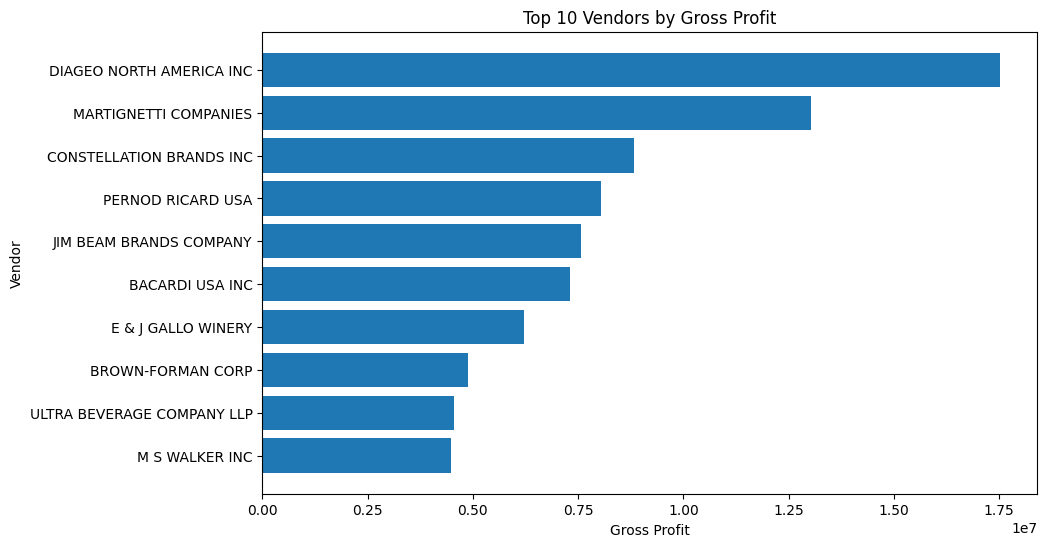

In [ ]:
top_vendors = vendor_overview.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_vendors["vendorname"].astype(str),
    top_vendors["gross_profit"]
)
plt.xlabel("Gross Profit")
plt.ylabel("Vendor")
plt.title("Top 10 Vendors by Gross Profit")
plt.gca().invert_yaxis()
plt.show()

#### 7.3 Profitability Analysis

Evaluate vendor profitability to identify suppliers that contribute strong margins versus those generating revenue with relatively lower profitability.

In [ ]:
profitability = (
    analytical_data[
        [
            "vendorname",
            "total_sales_revenue",
            "gross_profit",
            "profit_margin"
        ]
    ]
    .sort_values("profit_margin", ascending=False)
)

profitability.head(10)

,vendorname,total_sales_revenue,gross_profit,profit_margin
130,FLAVOR ESSENCE INC,"1,474.41","1,457.32",0.99
111,SILVER MOUNTAIN CIDERS,381.48,303.94,0.80
18,CAPSTONE INTERNATIONAL,246.87,191.96,0.78
26,ALISA CARR BEVERAGES,"118,167.38","83,043.70",0.70
76,STAR INDUSTRIES INC.,"7,914.72","5,449.99",0.69
116,THE PIERPONT GROUP LLC,"17,937.21","12,196.04",0.68
70,R.P.IMPORTS INC,"54,266.62","35,398.25",0.65
114,FANTASY FINE WINES CORP,327.59,198.34,0.61
91,VINEDREA WINES LLC,"11,385.60","6,703.47",0.59
30,BLACK PRINCE DISTILLERY INC,"11,818.85","5,815.93",0.49


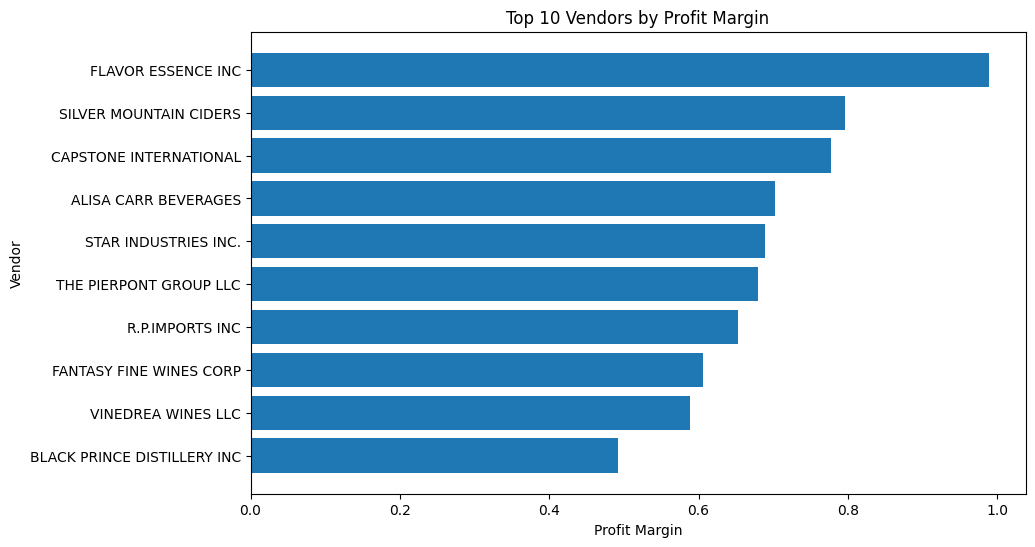

In [ ]:
top_margin = profitability.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_margin["vendorname"].astype(str),
    top_margin["profit_margin"]
)

plt.xlabel("Profit Margin")
plt.ylabel("Vendor")
plt.title("Top 10 Vendors by Profit Margin")
plt.gca().invert_yaxis()
plt.show()

#### 7.4 Cost Efficiency Analysis

Compare vendors based on procurement cost per purchased unit to identify differences in sourcing efficiency.

In [ ]:
cost_efficiency = (
    analytical_data[
        [
            "vendorname",
            "total_purchase_quantity",
            "avg_purchase_cost_per_unit",
            "gross_purchase_cost"
        ]
    ]
    .sort_values(
        "avg_purchase_cost_per_unit",
        ascending=True
    )
)

cost_efficiency.head(10)

,vendorname,total_purchase_quantity,avg_purchase_cost_per_unit,gross_purchase_cost
61,OLE SMOKY DISTILLERY LLC,"110,162.00",3.54,"389,544.69"
111,SILVER MOUNTAIN CIDERS,17.00,4.56,77.54
12,BRONCO WINE COMPANY,433.00,4.81,"2,082.43"
50,LAUREATE IMPORTS CO,29.00,4.88,141.66
81,TAKARA SAKE USA INC,"9,066.00",5.02,"45,522.33"
114,FANTASY FINE WINES CORP,24.00,5.39,129.25
92,WINE GROUP INC,"888,385.00",5.95,"5,285,737.20"
51,LATITUDE BEVERAGE COMPANY,"53,090.00",5.99,"318,056.76"
93,TREASURY WINE ESTATES,"497,770.00",6.01,"2,993,522.97"
88,WESTERN SPIRITS BEVERAGE CO,"56,860.00",6.39,"363,182.40"


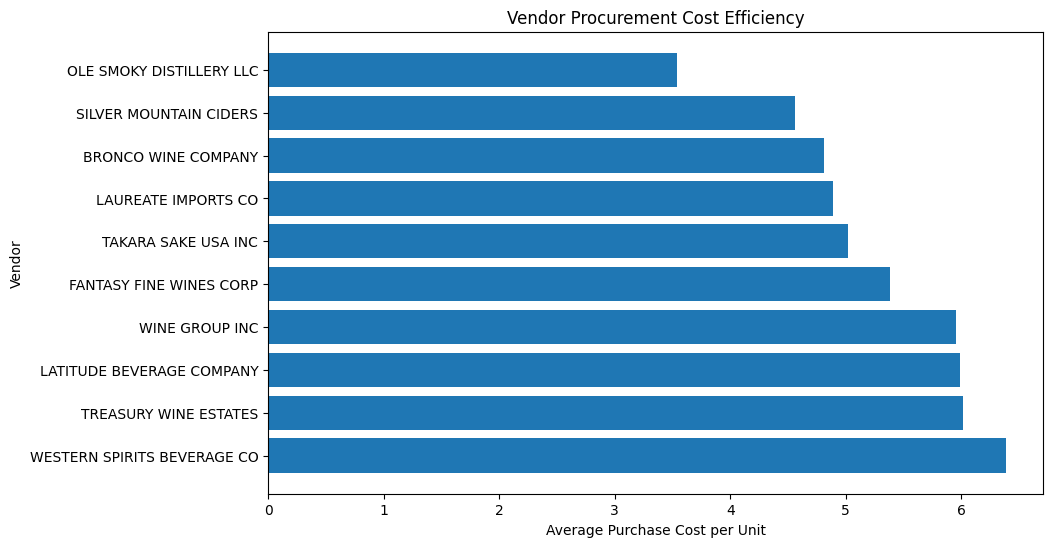

In [ ]:
top_cost_efficiency = cost_efficiency.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_cost_efficiency["vendorname"].astype(str),
    top_cost_efficiency["avg_purchase_cost_per_unit"]
)

plt.xlabel("Average Purchase Cost per Unit")
plt.ylabel("Vendor")
plt.title("Vendor Procurement Cost Efficiency")
plt.gca().invert_yaxis()
plt.show()

#### 7.5 Freight Cost Exposure

Analyze freight cost relative to procurement cost to identify vendors with higher logistics cost exposure.

In [ ]:
freight_analysis = (
    analytical_data[
        [
            "vendorname",
            "total_freight",
            "gross_purchase_cost",
            "freight_cost_ratio"
        ]
    ]
    .sort_values(
        "freight_cost_ratio",
        ascending=False
    )
)

freight_analysis.head(10)

,vendorname,total_freight,gross_purchase_cost,freight_cost_ratio
106,TALL SHIP DISTILLERY LLC,259.90,"48,705.48",0.01
88,WESTERN SPIRITS BEVERAGE CO,"1,933.19","363,182.40",0.01
42,HIGHLAND WINE MERCHANTS LLC,29.43,"5,529.75",0.01
3,ALTAMAR BRANDS LLC,62.39,"11,768.59",0.01
22,DIAGEO CHATEAU ESTATE WINES,"7,259.75","1,372,732.58",0.01
117,CANDIA VINEYARDS,194.13,"36,782.14",0.01
113,LABELLE VYDS AND WINERY,778.25,"147,617.80",0.01
130,FLAVOR ESSENCE INC,0.09,17.09,0.01
82,TRUETT HURST,1.25,237.89,0.01
95,Russian Standard Vodka,732.60,"139,639.87",0.01


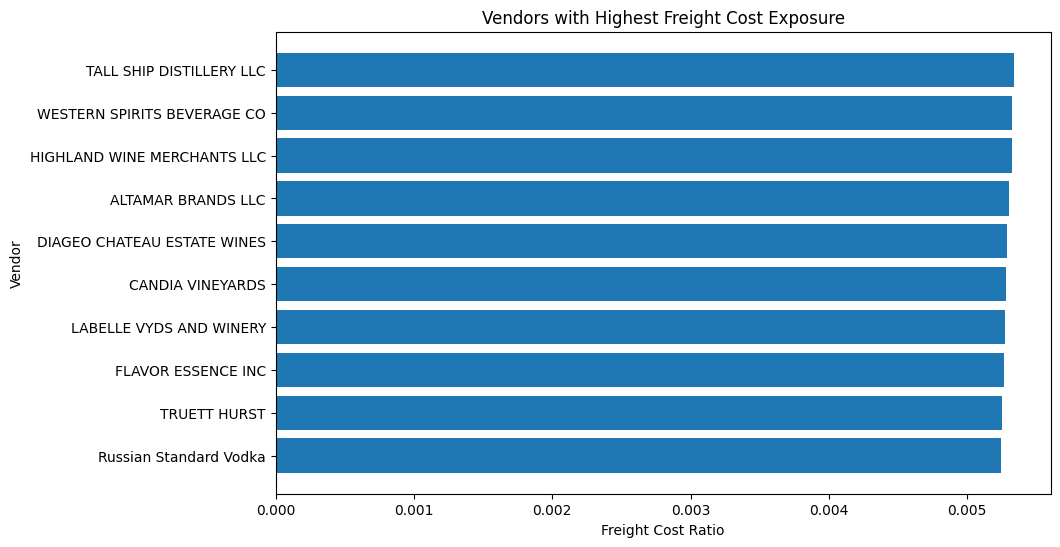

In [ ]:
top_freight = freight_analysis.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_freight["vendorname"].astype(str),
    top_freight["freight_cost_ratio"]
)

plt.xlabel("Freight Cost Ratio")
plt.ylabel("Vendor")
plt.title("Vendors with Highest Freight Cost Exposure")
plt.gca().invert_yaxis()
plt.show()

#### 7.6 Sales Volume Conversion

Analyze the relationship between purchased and sold quantities to identify differences in sales movement across vendors.

In [ ]:
volume_analysis = (
    analytical_data[
        [
            "vendorname",
            "total_purchase_quantity",
            "total_sales_quantity",
            "sales_volume_conversion"
        ]
    ]
    .sort_values(
        "sales_volume_conversion",
        ascending=False
    )
)

volume_analysis.head(10)

,vendorname,total_purchase_quantity,total_sales_quantity,sales_volume_conversion
130,FLAVOR ESSENCE INC,1.00,59.00,59.00
18,CAPSTONE INTERNATIONAL,4.00,13.00,3.25
111,SILVER MOUNTAIN CIDERS,17.00,52.00,3.06
76,STAR INDUSTRIES INC.,151.00,428.00,2.83
26,ALISA CARR BEVERAGES,438.00,"1,062.00",2.42
91,VINEDREA WINES LLC,205.00,440.00,2.15
70,R.P.IMPORTS INC,498.00,"1,038.00",2.08
116,THE PIERPONT GROUP LLC,580.00,"1,079.00",1.86
114,FANTASY FINE WINES CORP,24.00,41.00,1.71
30,BLACK PRINCE DISTILLERY INC,807.00,"1,115.00",1.38


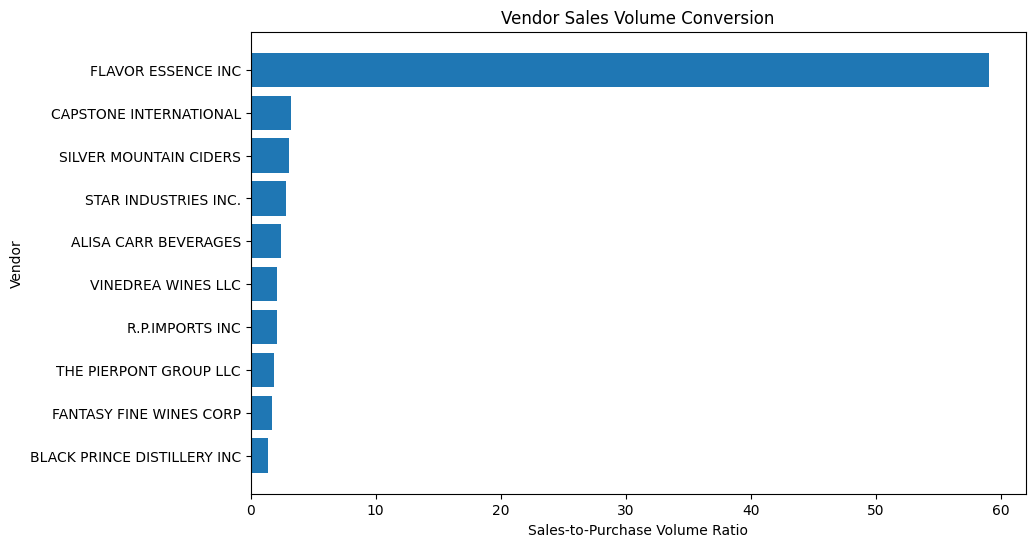

In [ ]:
top_conversion = volume_analysis.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_conversion["vendorname"].astype(str),
    top_conversion["sales_volume_conversion"]
)

plt.xlabel("Sales-to-Purchase Volume Ratio")
plt.ylabel("Vendor")
plt.title("Vendor Sales Volume Conversion")
plt.gca().invert_yaxis()
plt.show()

#### 7.7 Correlation Analysis

Examine relationships between key financial and operational metrics to identify potential drivers of vendor performance.

In [ ]:
correlation_features = [
    "gross_purchase_cost",
    "total_sales_revenue",
    "gross_profit",
    "profit_margin",
    "avg_purchase_cost_per_unit",
    "sales_volume_conversion",
    "freight_cost_ratio"
]

correlation_matrix = analytical_data[
    correlation_features
].corr()

correlation_matrix

,gross_purchase_cost,total_sales_revenue,gross_profit,profit_margin,avg_purchase_cost_per_unit,sales_volume_conversion,freight_cost_ratio
gross_purchase_cost,1.00,1.00,0.98,0.07,-0.09,-0.04,0.06
total_sales_revenue,1.00,1.00,0.99,0.07,-0.10,-0.04,0.05
gross_profit,0.98,0.99,1.00,0.07,-0.12,-0.04,0.06
profit_margin,0.07,0.07,0.07,1.00,0.01,0.09,-0.10
avg_purchase_cost_per_unit,-0.09,-0.10,-0.12,0.01,1.00,0.06,-0.26
sales_volume_conversion,-0.04,-0.04,-0.04,0.09,0.06,1.00,0.13
freight_cost_ratio,0.06,0.05,0.06,-0.10,-0.26,0.13,1.00


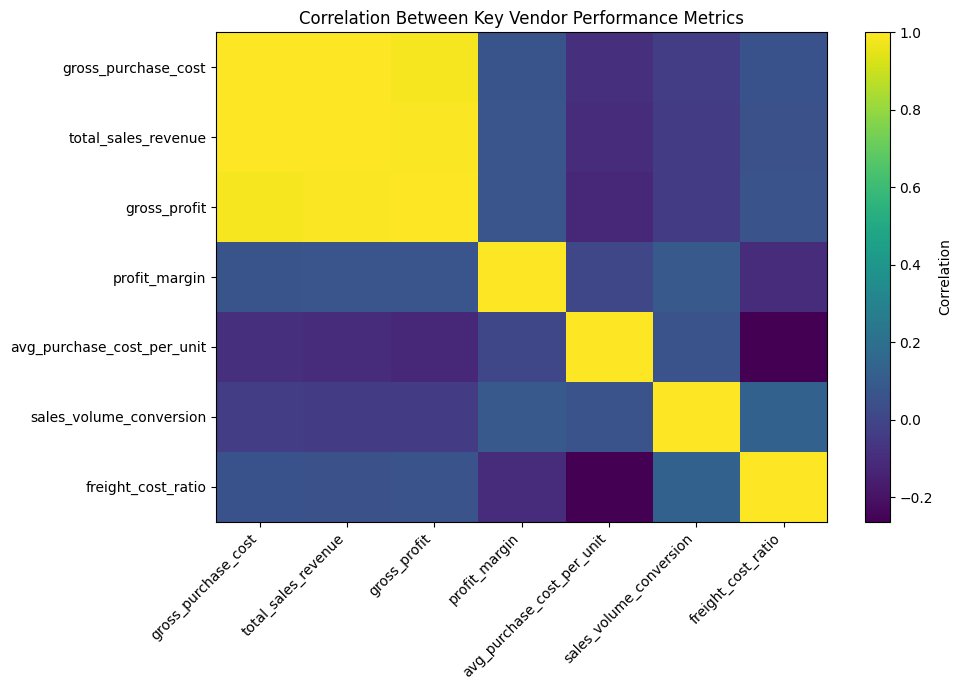

In [ ]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, aspect="auto")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.colorbar(label="Correlation")
plt.title("Correlation Between Key Vendor Performance Metrics")
plt.tight_layout()
plt.show()

**Interpretation**

A strong positive correlation between sales revenue and procurement cost would indicate that higher purchasing expenditure is generally associated with higher sales activity, but it does not establish that increased spending directly causes higher revenue.

### Step 8: Vendor Segmentation

This step segments vendors based on profitability, commercial contribution, and procurement efficiency to identify strategic supplier groups and support differentiated vendor management.

#### 8.1 Prepare Segmentation Metrics

Select the core performance metrics required to classify vendors based on profitability, commercial contribution, and procurement efficiency.

In [ ]:
segmentation_data = analytical_data.copy()

segmentation_data["procurement_efficiency"] = np.where(
    segmentation_data["gross_purchase_cost"] > 0,
    segmentation_data["total_sales_revenue"] / segmentation_data["gross_purchase_cost"],
    np.nan
)

segmentation_data["revenue_contribution"] = (
    segmentation_data["total_sales_revenue"]
    / segmentation_data["total_sales_revenue"].sum()
)

#### 8.2 Define Performance Benchmarks

Use median performance as the benchmark to distinguish relatively strong and weak vendor performance while limiting the influence of extreme values.

In [ ]:
profit_benchmark = segmentation_data["gross_profit"].median()
revenue_benchmark = segmentation_data["revenue_contribution"].median()
efficiency_benchmark = segmentation_data["procurement_efficiency"].median()

print(f"Gross Profit Benchmark: {profit_benchmark:,.2f}")
print(f"Revenue Contribution Benchmark: {revenue_benchmark:.2%}")
print(f"Procurement Efficiency Benchmark: {efficiency_benchmark:.2f}")

#### 8.3 Assign Vendor Segments

Classify vendors into actionable groups based on their relative profitability, commercial contribution, and procurement efficiency.

In [ ]:
# Create performance indicators

segmentation_data["profit_score"] = (
    segmentation_data["gross_profit"] >= segmentation_data["gross_profit"].median()
).astype(int)

segmentation_data["revenue_score"] = (
    segmentation_data["total_sales_revenue"] >= segmentation_data["total_sales_revenue"].median()
).astype(int)

segmentation_data["efficiency_score"] = (
    segmentation_data["procurement_efficiency"] >= segmentation_data["procurement_efficiency"].median()
).astype(int)

# Calculate total performance score

segmentation_data["performance_score"] = (
    segmentation_data["profit_score"]
    + segmentation_data["revenue_score"]
    + segmentation_data["efficiency_score"]
)

segmentation_data[
    [
        "vendorname",
        "performance_score"
    ]
].head()

,vendorname,performance_score
0,"IRA GOLDMAN AND WILLIAMS, LLP",0
1,AAPER ALCOHOL & CHEMICAL CO,0
2,ADAMBA IMPORTS INTL INC,0
3,ALTAMAR BRANDS LLC,0
4,AMERICAN SPIRITS EXCHANGE,1


#### 8.4 Assign Vendor Segments

Translate the performance score into actionable vendor segments for strategic supplier management.

In [ ]:
segmentation_data["vendor_segment"] = np.select(
    [
        segmentation_data["performance_score"] == 3,
        segmentation_data["performance_score"] == 2,
        segmentation_data["performance_score"] == 1,
        segmentation_data["performance_score"] == 0
    ],
    [
        "Strategic",
        "Development Opportunity",
        "Lower Priority",
        "Low Performance"
    ],
    default="Unclassified"
)

segmentation_data["vendor_segment"].value_counts()

,count
vendor_segment,
Low Performance,39
Strategic,36
Lower Priority,29
Development Opportunity,27


#### 8.5 Segment Distribution

Assess the composition of the vendor portfolio across the defined strategic segments.

In [ ]:
segment_distribution = (
    segmentation_data["vendor_segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "vendor_segment",
    "vendor_count"
]

segment_distribution

,vendor_segment,vendor_count
0,Low Performance,39
1,Strategic,36
2,Lower Priority,29
3,Development Opportunity,27


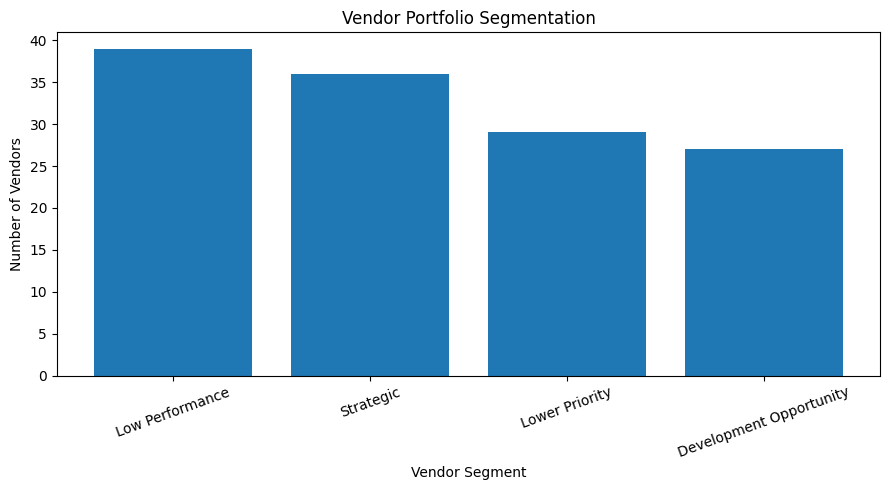

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    segment_distribution["vendor_segment"],
    segment_distribution["vendor_count"]
)

plt.xlabel("Vendor Segment")
plt.ylabel("Number of Vendors")
plt.title("Vendor Portfolio Segmentation")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#### 8.6 Compare Segment Performance

Evaluate the financial characteristics of each vendor segment to validate whether the segmentation creates meaningful differences in supplier performance.

In [ ]:
segment_performance = (
    segmentation_data
    .groupby("vendor_segment")
    .agg(
        vendor_count=("vendornumber", "nunique"),
        procurement_cost=("gross_purchase_cost", "sum"),
        sales_revenue=("total_sales_revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        avg_profit_margin=("profit_margin", "mean"),
        avg_procurement_efficiency=("procurement_efficiency", "mean")
    )
    .reset_index()
    .sort_values("gross_profit", ascending=False)
)

segment_performance

,vendor_segment,vendor_count,procurement_cost,sales_revenue,gross_profit,avg_profit_margin,avg_procurement_efficiency
3,Strategic,36,"157,232,405.93","231,314,845.16","74,082,439.23",0.32,1.48
0,Development Opportunity,27,"163,181,736.53","217,120,617.62","53,938,881.09",0.27,1.45
2,Lower Priority,29,"1,823,897.93","2,242,450.61","418,552.68",0.38,4.75
1,Low Performance,39,"1,303,199.83","1,385,038.63","81,981.06",-0.73,0.94


#### 8.7 Create Final Segmentation Dataset

Create the final vendor segmentation dataset for use in predictive modeling and business recommendations.

In [ ]:
vendor_segments = segmentation_data[
    [
        "vendornumber",
        "vendorname",
        "vendor_segment",
        "performance_score",
        "gross_purchase_cost",
        "total_sales_revenue",
        "gross_profit",
        "profit_margin",
        "procurement_efficiency",
        "freight_cost_ratio"
    ]
].copy()

vendor_segments.head()

,vendornumber,vendorname,vendor_segment,performance_score,gross_purchase_cost,total_sales_revenue,gross_profit,profit_margin,procurement_efficiency,freight_cost_ratio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",Low Performance,0,"5,657.96","1,265.58","-4,392.38",-3.47,0.22,0.00
1,54,AAPER ALCOHOL & CHEMICAL CO,Low Performance,0,105.55,NaN,NaN,NaN,NaN,0.00
2,60,ADAMBA IMPORTS INTL INC,Low Performance,0,"77,137.77","67,576.22","-9,561.55",-0.14,0.88,0.00
3,105,ALTAMAR BRANDS LLC,Low Performance,0,"11,768.59","15,748.75","3,980.16",0.25,1.34,0.01
4,200,AMERICAN SPIRITS EXCHANGE,Lower Priority,1,"1,211.35","1,719.97",508.62,0.30,1.42,0.01


### Step 9: Machine Learning

This step develops regression models to predict vendor gross profit using procurement, sales activity, and operational cost features.

The objective is to evaluate whether vendor-level operational characteristics can explain and predict profitability, while avoiding target leakage.

#### 9.1 Define Machine Learning Objective

The machine learning objective is to predict vendor gross profit based on procurement volume, purchasing activity, sales volume, and logistics costs.

Gross profit is treated as a continuous target variable, making this a regression problem.

#### 9.2 Define Target and Features

Select predictive features that represent procurement and operational activity while excluding variables directly derived from gross profit or post-calculated profitability metrics.

In [ ]:
# Target variable
target = "gross_profit"

# Predictive features
features = [
    "total_purchase_quantity",
    "total_purchase_spend",
    "purchase_orders",
    "total_sales_quantity",
    "total_sales_revenue",
    "invoice_count",
    "invoice_quantity",
    "invoice_spend",
    "total_freight",
    "avg_purchase_cost_per_unit",
    "freight_cost_ratio"
]

X = analytical_data[features].copy()
y = analytical_data[target].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (131, 11)
Target: (131,)


#### 9.3 Prepare Modeling Dataset

Prepare the modeling dataset by retaining observations with complete target and predictor information.

In [ ]:
model_data = pd.concat([X, y], axis=1).dropna()

X = model_data[features]
y = model_data[target]

print("Modeling dataset:", model_data.shape)

Modeling dataset: (126, 12)


#### 9.4 Train-Test Split

Split the dataset into training and testing sets to evaluate model performance on unseen vendor observations.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (100, 11)
Testing set: (26, 11)


#### 9.5 Baseline Model

Establish a Linear Regression baseline to provide a simple benchmark for evaluating more complex machine learning models.

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

#### 9.6 Random Forest Regression

Train a Random Forest Regressor to capture nonlinear relationships between vendor operational characteristics and gross profit.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(X_test)

#### 9.7 Model Evaluation

Evaluate model performance using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² to assess prediction accuracy from multiple perspectives.

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

model_results = pd.DataFrame([
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
])

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,0.00,0.00,1.00
1,Random Forest,"34,651.23","82,145.70",0.99


#### 9.8 Compare Model Performance

Compare the baseline and ensemble models to determine whether the nonlinear model provides meaningful predictive improvement.

In [ ]:
model_results.sort_values(
    "RMSE",
    ascending=True
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.00,0.00,1.00
1,Random Forest,"34,651.23","82,145.70",0.99


#### 9.9 Feature Importance

Identify the features that contribute most strongly to the Random Forest model's predictions to translate model output into actionable business insights.

In [ ]:
feature_importance = (
    pd.DataFrame({
        "feature": features,
        "importance": rf_model.feature_importances_
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_importance

,feature,importance
4,total_sales_revenue,0.29
6,invoice_quantity,0.13
8,total_freight,0.13
3,total_sales_quantity,0.11
1,total_purchase_spend,0.11
7,invoice_spend,0.11
0,total_purchase_quantity,0.10
10,freight_cost_ratio,0.01
2,purchase_orders,0.00
9,avg_purchase_cost_per_unit,0.00


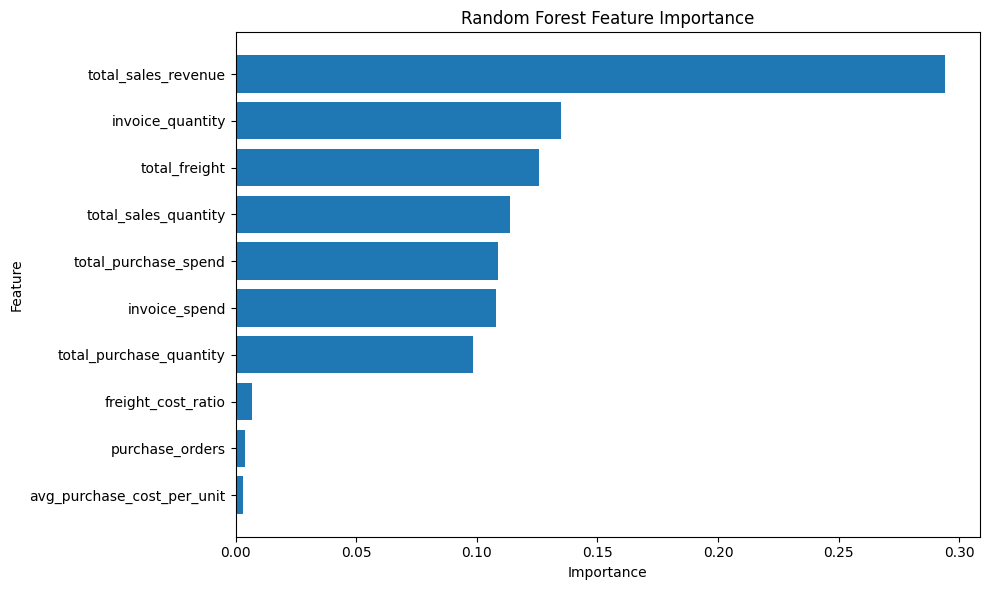

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### 9.10 Prediction vs Actual

Compare predicted and actual gross profit to assess how closely the selected model represents observed vendor profitability.

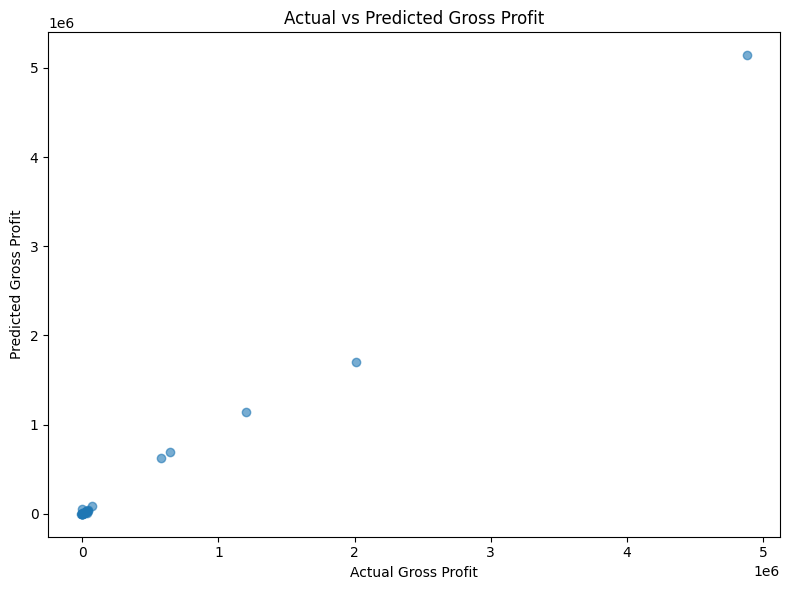

In [ ]:
best_predictions = rf_predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.xlabel("Actual Gross Profit")
plt.ylabel("Predicted Gross Profit")
plt.title("Actual vs Predicted Gross Profit")

plt.tight_layout()
plt.show()

#### 9.11 Final Model Output

Create a prediction table combining actual and predicted gross profit for further business interpretation.

In [ ]:
prediction_output = pd.DataFrame({
    "actual_gross_profit": y_test.values,
    "predicted_gross_profit": best_predictions
})

prediction_output["prediction_error"] = (
    prediction_output["actual_gross_profit"]
    - prediction_output["predicted_gross_profit"]
)

prediction_output.head()

,actual_gross_profit,predicted_gross_profit,prediction_error
0,"5,449.99",-928.30,"6,378.29"
1,"-6,681.78","-1,197.66","-5,484.12"
2,"10,858.24","8,178.09","2,680.15"
3,"35,398.25","4,111.70","31,286.55"
4,"10,801.32","8,011.81","2,789.51"


### Step 10: Business Insights & Recommendations

This step translates analytical and machine learning results into actionable business insights to support vendor prioritization, procurement efficiency, and profitability improvement.

#### 10.1 Identify Top Value-Creating Vendors

Identify vendors generating the highest gross profit to determine the suppliers with the greatest direct contribution to business profitability.

In [ ]:
top_profit_vendors = (
    vendor_segments[
        [
            "vendorname",
            "gross_purchase_cost",
            "total_sales_revenue",
            "gross_profit",
            "profit_margin",
            "vendor_segment"
        ]
    ]
    .sort_values("gross_profit", ascending=False)
    .head(10)
)

top_profit_vendors

,vendorname,gross_purchase_cost,total_sales_revenue,gross_profit,profit_margin,vendor_segment
43,DIAGEO NORTH AMERICA INC,"51,216,828.92","68,742,416.99","17,525,588.07",0.25,Development Opportunity
45,MARTIGNETTI COMPANIES,"28,006,619.26","41,047,306.30","13,040,687.04",0.32,Strategic
17,CONSTELLATION BRANDS INC,"15,653,446.89","24,469,172.93","8,815,726.04",0.36,Strategic
103,PERNOD RICARD USA,"24,247,871.78","32,281,247.95","8,033,376.17",0.25,Development Opportunity
99,JIM BEAM BRANDS COMPANY,"24,327,032.02","31,906,320.54","7,579,288.52",0.24,Development Opportunity
7,BACARDI USA INC,"17,713,664.99","25,014,556.89","7,300,891.90",0.29,Strategic
37,E & J GALLO WINERY,"12,351,575.00","18,556,085.61","6,204,510.61",0.33,Strategic
13,BROWN-FORMAN CORP,"13,598,034.76","18,478,557.47","4,880,522.71",0.26,Development Opportunity
83,ULTRA BEVERAGE COMPANY LLP,"13,278,668.63","17,822,938.45","4,544,269.82",0.25,Development Opportunity
86,M S WALKER INC,"10,991,369.12","15,465,247.75","4,473,878.63",0.29,Strategic


**Business Insight**

The analysis identifies the vendors contributing the largest absolute gross profit. These suppliers should receive greater strategic attention because changes in their commercial performance may have a material impact on overall profitability.

#### 10.2 Identify High-Revenue but Low-Efficiency Vendors

Identify commercially important vendors whose procurement efficiency is below the portfolio benchmark, highlighting potential cost optimization opportunities.

In [ ]:
# Calculate portfolio benchmarks directly from segmentation_data

revenue_median = segmentation_data["total_sales_revenue"].median()
efficiency_median = segmentation_data["procurement_efficiency"].median()

# Filter vendors requiring efficiency attention

efficiency_opportunities = segmentation_data[
    (segmentation_data["total_sales_revenue"] >= revenue_median) &
    (segmentation_data["procurement_efficiency"] < efficiency_median)
]

# Select relevant business metrics

efficiency_opportunities = efficiency_opportunities[
    [
        "vendorname",
        "total_sales_revenue",
        "gross_purchase_cost",
        "gross_profit",
        "profit_margin",
        "procurement_efficiency",
        "freight_cost_ratio"
    ]
].sort_values(
    "total_sales_revenue",
    ascending=False
)

efficiency_opportunities.head(10)

,vendorname,total_sales_revenue,gross_purchase_cost,gross_profit,profit_margin,procurement_efficiency,freight_cost_ratio
43,DIAGEO NORTH AMERICA INC,"68,742,416.99","51,216,828.92","17,525,588.07",0.25,1.34,0.01
103,PERNOD RICARD USA,"32,281,247.95","24,247,871.78","8,033,376.17",0.25,1.33,0.01
99,JIM BEAM BRANDS COMPANY,"31,906,320.54","24,327,032.02","7,579,288.52",0.24,1.31,0.01
13,BROWN-FORMAN CORP,"18,478,557.47","13,598,034.76","4,880,522.71",0.26,1.36,0.01
83,ULTRA BEVERAGE COMPANY LLP,"17,822,938.45","13,278,668.63","4,544,269.82",0.25,1.34,0.01
71,SAZERAC CO INC,"13,250,928.19","9,967,063.88","3,283,864.31",0.25,1.33,0.01
39,WILLIAM GRANT & SONS INC,"7,635,828.27","5,990,978.77","1,644,849.50",0.22,1.27,0.01
97,CAMPARI AMERICA,"5,610,527.44","4,162,685.52","1,447,841.92",0.26,1.35,0.01
77,"STOLI GROUP,(USA) LLC","4,663,847.60","3,685,023.21","978,824.39",0.21,1.27,0.01
66,REMY COINTREAU USA INC,"4,294,875.05","3,371,936.95","922,938.10",0.21,1.27,0.01


#### 10.3 Identify Freight Cost Exposure

Identify vendors with relatively high freight cost exposure to assess whether logistics costs are materially affecting procurement efficiency.

In [ ]:
freight_exposure = (
    analytical_data[
        [
            "vendorname",
            "gross_purchase_cost",
            "total_freight",
            "freight_cost_ratio",
            "gross_profit",
            "profit_margin"
        ]
    ]
    .sort_values("freight_cost_ratio", ascending=False)
    .head(10)
)

freight_exposure

,vendorname,gross_purchase_cost,total_freight,freight_cost_ratio,gross_profit,profit_margin
106,TALL SHIP DISTILLERY LLC,"48,705.48",259.90,0.01,827.66,0.02
88,WESTERN SPIRITS BEVERAGE CO,"363,182.40","1,933.19",0.01,"80,035.31",0.18
42,HIGHLAND WINE MERCHANTS LLC,"5,529.75",29.43,0.01,"-3,996.07",-2.61
3,ALTAMAR BRANDS LLC,"11,768.59",62.39,0.01,"3,980.16",0.25
22,DIAGEO CHATEAU ESTATE WINES,"1,372,732.58","7,259.75",0.01,"812,298.31",0.37
117,CANDIA VINEYARDS,"36,782.14",194.13,0.01,"15,841.19",0.30
113,LABELLE VYDS AND WINERY,"147,617.80",778.25,0.01,"55,449.90",0.27
130,FLAVOR ESSENCE INC,17.09,0.09,0.01,"1,457.32",0.99
82,TRUETT HURST,237.89,1.25,0.01,-222.90,-14.87
95,Russian Standard Vodka,"139,639.87",732.60,0.01,-312.44,-0.00


**Business Insight**

Vendors with elevated freight cost ratios may offer opportunities for logistics optimization, particularly where high freight exposure coincides with significant procurement spending.

#### 10.4 Evaluate Vendor Segmentation

Evaluate the financial contribution of each vendor segment to identify which supplier groups should receive strategic attention.

In [ ]:
segment_summary = (
    segmentation_data
    .groupby("vendor_segment")
    .agg(
        vendors=("vendornumber", "nunique"),
        procurement_cost=("gross_purchase_cost", "sum"),
        sales_revenue=("total_sales_revenue", "sum"),
        gross_profit=("gross_profit", "sum")
    )
    .reset_index()
)

segment_summary["profit_contribution"] = (
    segment_summary["gross_profit"]
    / segment_summary["gross_profit"].sum()
)

segment_summary.sort_values(
    "gross_profit",
    ascending=False
)

,vendor_segment,vendors,procurement_cost,sales_revenue,gross_profit,profit_contribution
3,Strategic,36,"157,232,405.93","231,314,845.16","74,082,439.23",0.58
0,Development Opportunity,27,"163,181,736.53","217,120,617.62","53,938,881.09",0.42
2,Lower Priority,29,"1,823,897.93","2,242,450.61","418,552.68",0.00
1,Low Performance,39,"1,303,199.83","1,385,038.63","81,981.06",0.00


#### 10.5 Evaluate Machine Learning Drivers

Use model feature importance to identify operational variables most associated with gross profit predictions and translate them into potential business drivers.

In [ ]:
feature_importance.head(10)

,feature,importance
4,total_sales_revenue,0.29
6,invoice_quantity,0.13
8,total_freight,0.13
3,total_sales_quantity,0.11
1,total_purchase_spend,0.11
7,invoice_spend,0.11
0,total_purchase_quantity,0.10
10,freight_cost_ratio,0.01
2,purchase_orders,0.00
9,avg_purchase_cost_per_unit,0.00


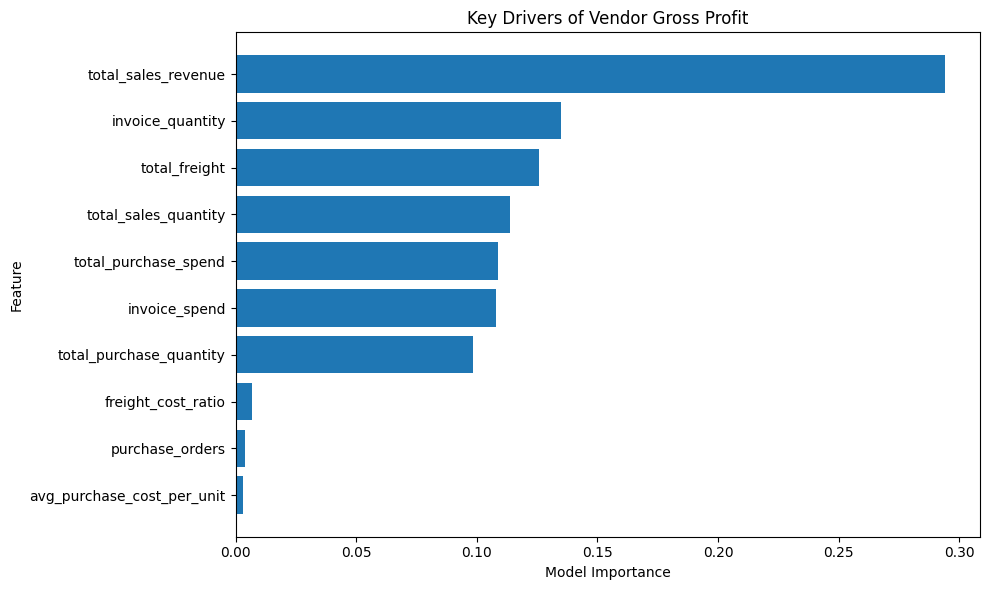

In [ ]:
top_ml_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_ml_features["feature"],
    top_ml_features["importance"]
)

plt.xlabel("Model Importance")
plt.ylabel("Feature")
plt.title("Key Drivers of Vendor Gross Profit")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

#### 10.6 Quantify Business Priorities

Quantify the financial contribution and efficiency characteristics of priority vendor groups to support evidence-based decision-making.

In [ ]:
business_summary = {
    "total_vendors": analytical_data["vendornumber"].nunique(),
    "total_procurement_cost": analytical_data["gross_purchase_cost"].sum(),
    "total_sales_revenue": analytical_data["total_sales_revenue"].sum(),
    "total_gross_profit": analytical_data["gross_profit"].sum(),
    "median_profit_margin": analytical_data["profit_margin"].median(),
    "median_freight_ratio": analytical_data["freight_cost_ratio"].median()
}

business_summary

{'total_vendors': 129,
 'total_procurement_cost': np.float64(323541240.22),
 'total_sales_revenue': np.float64(452062952.02),
 'total_gross_profit': np.float64(128521854.05999999),
 'median_profit_margin': 0.26685760255378305,
 'median_freight_ratio': 0.005055361796473033}

#### 10.7 Final Business Recommendations

Based on the combined findings from exploratory analysis, vendor segmentation, and predictive modeling, the following actions are recommended:

1. **Protect Strategic Vendors**
   Prioritize high-profit, commercially significant vendors through stronger relationship management and supply continuity planning.

2. **Improve Procurement Efficiency**
   Review pricing and purchasing terms for high-revenue vendors with below-benchmark procurement efficiency.

3. **Optimize Logistics Costs**
   Investigate vendors with elevated freight cost ratios and evaluate opportunities for order consolidation, delivery optimization, or revised freight agreements.

4. **Use Data-Driven Vendor Prioritization**
   Apply the vendor segmentation framework to differentiate supplier management strategies instead of using a one-size-fits-all approach.

5. **Monitor Key Profitability Drivers**
   Use the machine learning model as a decision-support tool to monitor operational factors associated with gross profit and identify areas requiring further investigation.

In [141]:
df.columns.tolist()

['vendornumber',
 'vendorname',
 'brand',
 'description',
 'purchaseprice',
 'actualprice',
 'volume',
 'totalpurchasequantity',
 'totalpurchasedollars',
 'totalsalesquantity',
 'totalsalesprice',
 'totalsalesdollars',
 'totalexcisetax',
 'freightcost',
 'grossprofit',
 'profitmargin',
 'stockturnover',
 'salestopurchaseratio']